# 03 - Nettoyage des Données

**Phase 2**

Objectif : nettoyer `data/dataset.csv` en traitant les valeurs manquantes, les doublons, les incohérences métier et les outliers, puis produire `data/dataset_cleaned.csv` et documenter les décisions dans `preprocessing_decisions.md`.

## 1. Imports et chargement

In [85]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

DATA_PATH = Path("../data/dataset.csv")
CLEAN_PATH = Path("../data/dataset_cleaned.csv")
BOXPLOT_PATH = Path("../data/outliers_boxplot.png")

df = pd.read_csv(DATA_PATH, dtype={"route_of_admin": "string"})
df["route_of_admin"] = df["route_of_admin"].apply(
    lambda x: str(int(float(x))).zfill(3) if pd.notna(x) else pd.NA
)
df_original = df.copy()

numeric_cols = ["patient_age", "nb_drugs", "nb_reactions", "worst_reaction_outcome", "nb_suspect_drugs"]
categorical_cols = ["patient_sex", "reporter_qualification", "route_of_admin", "country", "has_black_box_warning", "is_concomitant_present"]
target_col = "seriousnesshospitalization"

print(f"Dataset chargé : {df.shape[0]:,} lignes x {df.shape[1]} colonnes")
df.head()

Dataset chargé : 10,200 lignes x 12 colonnes


,patient_age,nb_drugs,nb_reactions,worst_reaction_outcome,nb_suspect_drugs,patient_sex,reporter_qualification,route_of_admin,country,has_black_box_warning,is_concomitant_present,seriousnesshospitalization
0,26.0,1,2,NaN,1,1.0,3.0,041,NaN,0,0,0
1,77.0,1,4,NaN,1,2.0,5.0,042,NaN,0,0,0
2,NaN,1,2,NaN,1,2.0,5.0,<NA>,NaN,0,0,0
3,NaN,1,1,6.0,1,1.0,5.0,<NA>,US,0,0,0
4,NaN,9,1,6.0,9,2.0,1.0,<NA>,US,1,0,0


## 2. Tâche 2.1 - Valeurs manquantes

On calcule d'abord le taux de valeurs manquantes pour chaque variable. Les imputations seront appliquées après suppression des doublons exacts bruts, afin que les doublons ne biaisent pas les statistiques utilisées pour l'imputation.

In [86]:
missing_table_initial = pd.DataFrame({
    "Variable": df.columns,
    "Manquants": df.isna().sum().values,
    "Taux (%)": (df.isna().mean().values * 100).round(2),
    "Type": df.dtypes.astype(str).values,
}).query("Manquants > 0").sort_values("Taux (%)", ascending=False)

missing_table_initial

,Variable,Manquants,Taux (%),Type
0,patient_age,3425,33.58,float64
7,route_of_admin,2186,21.43,object
3,worst_reaction_outcome,662,6.49,float64
8,country,538,5.27,object
6,reporter_qualification,332,3.25,float64
5,patient_sex,75,0.74,float64


## 3. Tâche 2.2 - Doublons exacts et incohérences

Les doublons exacts sont supprimés avant imputation. C'est important : si on impute d'abord, plusieurs lignes différentes avec des valeurs manquantes peuvent devenir artificiellement identiques.

In [87]:
raw_duplicates = df.duplicated().sum()
print(f"Doublons exacts avant imputation : {raw_duplicates:,}")

df = df.drop_duplicates().copy()
print(f"Après suppression des doublons bruts : {df.shape[0]:,} lignes x {df.shape[1]} colonnes")

Doublons exacts avant imputation : 2,042
Après suppression des doublons bruts : 8,158 lignes x 12 colonnes


In [88]:
# Incohérence métier : certains âges sont impossibles en années.
# Dans FAERS, ces valeurs correspondent très probablement à des âges stockés en jours.
invalid_age_before = df[(df["patient_age"] < 0) | (df["patient_age"] > 120)]["patient_age"]
print(f"Âges invalides avant correction : {len(invalid_age_before)}")
print(sorted(invalid_age_before.dropna().unique()))

def correct_age(value):
    if pd.isna(value):
        return np.nan
    if value > 120:
        converted = value / 365.25
        if 0 <= converted <= 120:
            return round(converted, 2)
        return np.nan
    if value < 0:
        return np.nan
    return value

df["patient_age"] = df["patient_age"].apply(correct_age)
invalid_age_after = df[(df["patient_age"] < 0) | (df["patient_age"] > 120)]
print(f"Âges invalides après correction : {len(invalid_age_after)}")
print(f"Plage finale avant imputation : {df['patient_age'].min()} - {df['patient_age'].max()} ans")

Âges invalides avant correction : 9
[np.float64(604.0), np.float64(905.0), np.float64(16430.0), np.float64(19639.0), np.float64(22240.0), np.float64(22928.0), np.float64(23628.0), np.float64(24434.0), np.float64(32193.0)]
Âges invalides après correction : 0
Plage finale avant imputation : 0.0 - 103.0 ans


In [89]:
validation_rules = {
    "patient_age is missing or in [0, 120]": df["patient_age"].isna() | df["patient_age"].between(0, 120),
    "nb_drugs >= 1": df["nb_drugs"] >= 1,
    "nb_reactions >= 1": df["nb_reactions"] >= 1,
    "nb_suspect_drugs >= 0": df["nb_suspect_drugs"] >= 0,
    "nb_suspect_drugs <= nb_drugs": df["nb_suspect_drugs"] <= df["nb_drugs"],
    "worst_reaction_outcome is missing or in {1,2,3,4,5,6}": df["worst_reaction_outcome"].isna() | df["worst_reaction_outcome"].isin([1, 2, 3, 4, 5, 6]),
    "patient_sex is missing or in {0,1,2}": df["patient_sex"].isna() | df["patient_sex"].isin([0, 1, 2]),
    "reporter_qualification is missing or in {1,2,3,4,5}": df["reporter_qualification"].isna() | df["reporter_qualification"].isin([1, 2, 3, 4, 5]),
    "has_black_box_warning in {0,1}": df["has_black_box_warning"].isin([0, 1]),
    "is_concomitant_present in {0,1}": df["is_concomitant_present"].isin([0, 1]),
    "seriousnesshospitalization in {0,1}": df["seriousnesshospitalization"].isin([0, 1]),
    "country is missing or ISO-like 2-letter code": df["country"].isna() | df["country"].astype(str).str.fullmatch(r"[A-Z]{2}"),
    "route_of_admin is missing or numeric FDA code": df["route_of_admin"].isna() | df["route_of_admin"].astype(str).str.replace(r"\.0$", "", regex=True).str.fullmatch(r"\d+"),
}

validation_summary = pd.DataFrame([
    {
        "Vérification": rule,
        "OK": mask.all(),
        "Violations": int((~mask).sum())
    }
    for rule, mask in validation_rules.items()
])

validation_summary

,Vérification,OK,Violations
0,"patient_age is missing or in [0, 120]",True,0
1,nb_drugs >= 1,True,0
2,nb_reactions >= 1,True,0
3,nb_suspect_drugs >= 0,True,0
4,nb_suspect_drugs <= nb_drugs,True,0
5,"worst_reaction_outcome is missing or in {1,2,3...",True,0
6,"patient_sex is missing or in {0,1,2}",True,0
7,"reporter_qualification is missing or in {1,2,3...",True,0
8,"has_black_box_warning in {0,1}",True,0
9,"is_concomitant_present in {0,1}",True,0


## 4. Imputation des valeurs manquantes

Stratégies retenues : médiane pour `patient_age`, mode pour les variables catégorielles ou ordinales codées.

In [90]:
missing_before_imputation = df.isna().sum()

imputation_plan = {
    "patient_age": {
        "strategy": "Médiane",
        "value": df["patient_age"].median(),
        "justification": "Variable numérique avec outliers ; médiane robuste."
    },
    "worst_reaction_outcome": {
        "strategy": "Mode",
        "value": df["worst_reaction_outcome"].mode(dropna=True)[0],
        "justification": "Variable codée FDA ; le mode correspond à la modalité la plus fréquente."
    },
    "route_of_admin": {
        "strategy": "Mode",
        "value": df["route_of_admin"].mode(dropna=True)[0],
        "justification": "Variable catégorielle ; conservation des lignes."
    },
    "country": {
        "strategy": "Mode",
        "value": df["country"].mode(dropna=True)[0],
        "justification": "Variable catégorielle ; pays majoritaire utilisé."
    },
    "reporter_qualification": {
        "strategy": "Mode",
        "value": df["reporter_qualification"].mode(dropna=True)[0],
        "justification": "Variable catégorielle codée ; taux de manque modéré."
    },
    "patient_sex": {
        "strategy": "Mode",
        "value": df["patient_sex"].mode(dropna=True)[0],
        "justification": "Variable catégorielle codée ; taux de manque faible."
    },
}

for col, info in imputation_plan.items():
    df[col] = df[col].fillna(info["value"])

imputation_table = pd.DataFrame([
    {
        "Variable": col,
        "Manquants avant": int(missing_before_imputation[col]),
        "Stratégie": info["strategy"],
        "Valeur imputée": info["value"],
        "Manquants après": int(df[col].isna().sum()),
        "Justification": info["justification"],
    }
    for col, info in imputation_plan.items()
])

print(f"Valeurs manquantes restantes : {df.isna().sum().sum()}")
imputation_table

Valeurs manquantes restantes : 0


,Variable,Manquants avant,Stratégie,Valeur imputée,Manquants après,Justification
0,patient_age,1916,Médiane,60.0,0,Variable numérique avec outliers ; médiane rob...
1,worst_reaction_outcome,632,Mode,6.0,0,Variable codée FDA ; le mode correspond à la m...
2,route_of_admin,1754,Mode,048,0,Variable catégorielle ; conservation des lignes.
3,country,516,Mode,US,0,Variable catégorielle ; pays majoritaire utilisé.
4,reporter_qualification,318,Mode,5.0,0,Variable catégorielle codée ; taux de manque m...
5,patient_sex,71,Mode,2.0,0,Variable catégorielle codée ; taux de manque f...


In [91]:
# Vérification finale : l'imputation peut créer quelques lignes identiques.
post_imputation_duplicates = df.duplicated().sum()
print(f"Doublons exacts après imputation : {post_imputation_duplicates:,}")

df = df.drop_duplicates().copy()
print(f"Dataset après suppression finale des doublons : {df.shape[0]:,} lignes x {df.shape[1]} colonnes")
print(f"Doublons restants : {df.duplicated().sum()}")

Doublons exacts après imputation : 411
Dataset après suppression finale des doublons : 7,747 lignes x 12 colonnes
Doublons restants : 0


## 5. Tâche 2.3 - Outliers

Les outliers sont détectés par IQR et Z-score. Dans ce dataset, les outliers numériques valides sont conservés car ils peuvent porter un signal de sévérité clinique.

In [92]:
outlier_cols = ["patient_age", "nb_drugs", "nb_reactions", "nb_suspect_drugs"]
outlier_rows = []

for col in outlier_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    iqr_count = int(((df[col] < lower) | (df[col] > upper)).sum())
    std = df[col].std(ddof=0)
    z_count = int(((df[col] - df[col].mean()).abs() / std > 3).sum()) if std != 0 else 0
    outlier_rows.append({
        "Variable": col,
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "Borne inférieure": lower,
        "Borne supérieure": upper,
        "Outliers IQR": iqr_count,
        "Outliers Z-score": z_count,
        "Décision": "Conserver si métier-valide",
    })

outlier_table = pd.DataFrame(outlier_rows)
outlier_table

,Variable,Q1,Q3,IQR,Borne inférieure,Borne supérieure,Outliers IQR,Outliers Z-score,Décision
0,patient_age,51.0,68.0,17.0,25.5,93.5,536,95,Conserver si métier-valide
1,nb_drugs,1.0,5.0,4.0,-5.0,11.0,398,148,Conserver si métier-valide
2,nb_reactions,1.0,4.0,3.0,-3.5,8.5,399,132,Conserver si métier-valide
3,nb_suspect_drugs,1.0,2.0,1.0,-0.5,3.5,711,141,Conserver si métier-valide


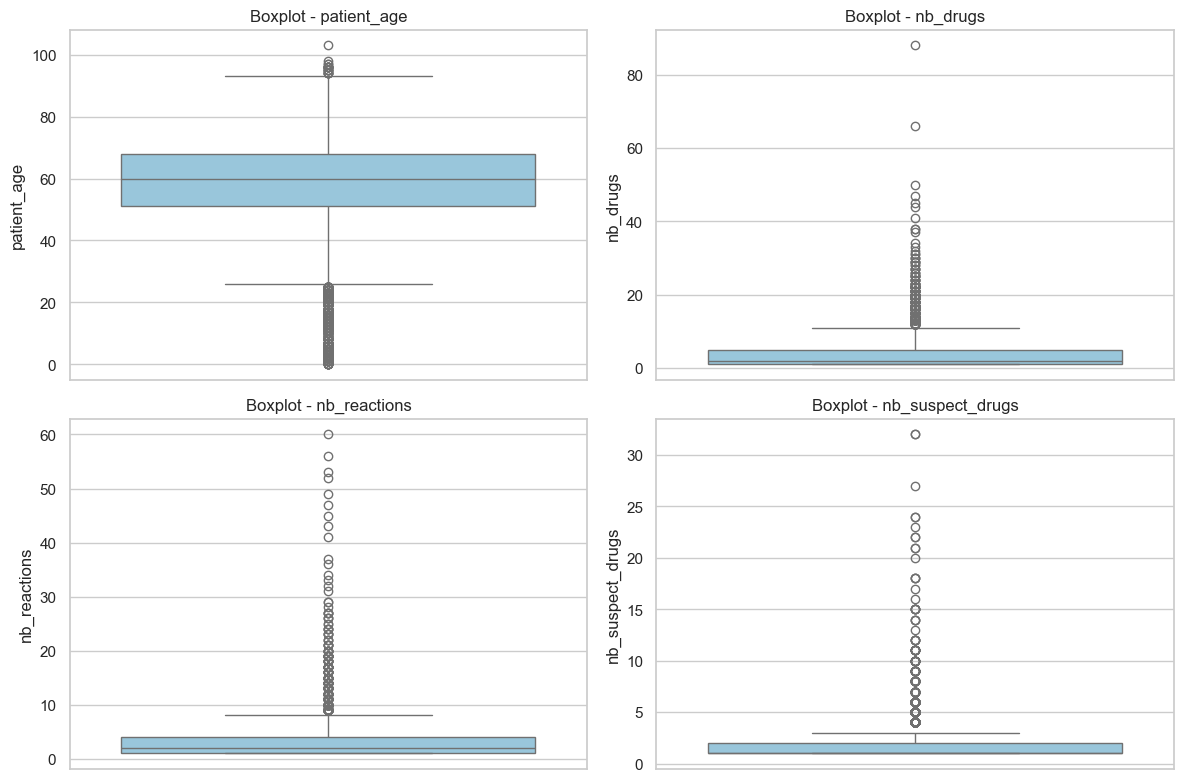

Boxplots sauvegardés : ..\data\outliers_boxplot.png


In [93]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.ravel()

for ax, col in zip(axes, outlier_cols):
    sns.boxplot(y=df[col], ax=ax, color="#8ecae6")
    ax.set_title(f"Boxplot - {col}")

plt.tight_layout()
fig.savefig(BOXPLOT_PATH, dpi=150, bbox_inches="tight")
plt.show()

print(f"Boxplots sauvegardés : {BOXPLOT_PATH}")

## 6. Tâche 2.4 - Tableau récapitulatif

In [94]:
decisions = pd.DataFrame([
    ["patient_age", "Manquants + 9 âges > 120", "Conversion jours->années puis imputation médiane", "Âges FAERS parfois exprimés en jours ; médiane robuste"],
    ["nb_drugs", "Outliers statistiques", "Conservation", "Polymédication plausible et informative"],
    ["nb_reactions", "Outliers statistiques", "Conservation", "Multiples réactions plausibles et informatives"],
    ["worst_reaction_outcome", "Manquants", "Imputation mode 6", "6 = unknown, cohérent métier"],
    ["nb_suspect_drugs", "Outliers statistiques", "Conservation", "Multiples suspects plausibles"],
    ["patient_sex", "Manquants faibles", "Imputation mode", "Variable catégorielle FDA"],
    ["reporter_qualification", "Manquants", "Imputation mode", "Variable catégorielle FDA"],
    ["route_of_admin", "Manquants", "Imputation mode", "Variable catégorielle FDA"],
    ["country", "Manquants", "Imputation mode", "Pays majoritaire utilisé"],
    ["has_black_box_warning", "Aucun", "Aucune action", "Binaire valide"],
    ["is_concomitant_present", "Aucun", "Aucune action", "Binaire valide"],
    ["seriousnesshospitalization", "Aucun", "Aucune action", "Cible binaire valide"],
    ["Toutes les colonnes", "Doublons exacts", "Suppression", "Évite la surpondération"],
], columns=["Variable", "Problème détecté", "Action effectuée", "Justification"])

decisions

,Variable,Problème détecté,Action effectuée,Justification
0,patient_age,Manquants + 9 âges > 120,Conversion jours->années puis imputation médiane,Âges FAERS parfois exprimés en jours ; médiane...
1,nb_drugs,Outliers statistiques,Conservation,Polymédication plausible et informative
2,nb_reactions,Outliers statistiques,Conservation,Multiples réactions plausibles et informatives
3,worst_reaction_outcome,Manquants,Imputation mode 6,"6 = unknown, cohérent métier"
4,nb_suspect_drugs,Outliers statistiques,Conservation,Multiples suspects plausibles
5,patient_sex,Manquants faibles,Imputation mode,Variable catégorielle FDA
6,reporter_qualification,Manquants,Imputation mode,Variable catégorielle FDA
7,route_of_admin,Manquants,Imputation mode,Variable catégorielle FDA
8,country,Manquants,Imputation mode,Pays majoritaire utilisé
9,has_black_box_warning,Aucun,Aucune action,Binaire valide


## 6. Feature Engineering

Nous créons deux nouvelles variables dérivées :
1. `age_group` : Catégorisation de l'âge (Enfant, Adulte, Senior).
2. `polypharmacy` : Indicateur binaire si le patient prend plus de 5 médicaments.

In [ ]:
def create_features(df_in):
    df_out = df_in.copy()
    
    # 1. Age groups
    bins = [0, 18, 65, 120]
    labels = ['Enfant', 'Adulte', 'Senior']
    df_out['age_group'] = pd.cut(df_out['patient_age'], bins=bins, labels=labels, include_lowest=True)
    
    # 2. Polypharmacy (nb_drugs > 5)
    df_out['polypharmacy'] = (df_out['nb_drugs'] > 5).astype(int)
    
    return df_out

df = create_features(df)
categorical_cols.append('age_group')
categorical_cols.append('polypharmacy')

print("Nouvelles features créées.")
df[['patient_age', 'age_group', 'nb_drugs', 'polypharmacy']].head()

## 7. Construction du Pipeline de Preprocessing

Nous utilisons `ColumnTransformer` pour appliquer des transformations spécifiques à chaque type de colonne.

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
import joblib

# Redéfinition des colonnes pour le pipeline
num_features = ["patient_age", "nb_drugs", "nb_reactions", "worst_reaction_outcome", "nb_suspect_drugs"]
cat_features = ["patient_sex", "reporter_qualification", "route_of_admin", "country", "has_black_box_warning", "is_concomitant_present", "age_group", "polypharmacy"]

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_features),
        ('cat', categorical_transformer, cat_features)
    ]
)

print("Pipeline de preprocessing défini.")

## 8. Séparation Train / Validation / Test

Séparation stratifiée (70% Train, 15% Validation, 15% Test).

In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=[target_col])
y = df[target_col]

X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.1765, random_state=42, stratify=y_train_val
) # 0.1765 * 0.85 approx 0.15

print(f"Train set      : {X_train.shape[0]} samples")
print(f"Validation set : {X_val.shape[0]} samples")
print(f"Test set       : {X_test.shape[0]} samples")

## 9. Stratégies de gestion du déséquilibre

En Phase 3, nous testerons :
1. Baseline (pas de rééquilibrage).
2. Oversampling (SMOTE).
3. Undersampling (RandomUnderSampler).

Ces étapes seront intégrées dans un `imblearn.pipeline.Pipeline`.

## 10. Exports

Sauvegarde du pipeline et des datasets.

In [ ]:
# Fit du preprocessor sur le train set uniquement (pour éviter le data leakage)
preprocessor.fit(X_train)

# Sauvegarde du pipeline
joblib.dump(preprocessor, "../models/preprocessor.joblib")

# Sauvegarde des datasets
PROCESSED_DIR = Path("../data/processed")
X_train.assign(**{target_col: y_train}).to_csv(PROCESSED_DIR / "train.csv", index=False)
X_val.assign(**{target_col: y_val}).to_csv(PROCESSED_DIR / "validation.csv", index=False)
X_test.assign(**{target_col: y_test}).to_csv(PROCESSED_DIR / "test.csv", index=False)

print("Pipeline sérialisé et datasets sauvegardés.")